# ESM MLP for Full GO Prediction

## Project goal
In this notebook, we train a multi-label MLP model to predict Gene Ontology (GO) terms from pretrained ESM protein embeddings.

This experiment uses the **full GO label space**, meaning we keep all GO terms rather than filtering to only frequent labels.  
The purpose is to build a stronger sequence-based baseline than k-mer features while preserving the real difficulty of the CAFA-style prediction task:
- large output space
- severe class imbalance
- extremely sparse labels
- multi-label protein function prediction

## Why this notebook matters
The earlier preprocessing workflow already:
- cleaned and aligned protein sequences
- generated ESM embeddings for each protein
- encoded GO terms into a multi-label target matrix
- saved metadata such as protein IDs and GO vocabularies

This notebook begins at the **supervised modeling stage**, using pretrained sequence representations as direct input to an MLP classifier.

## Input / output summary
- **Input features:** mean-pooled ESM2 protein embeddings, dimension = 640
- **Output labels:** all GO terms, dimension = 31,454
- **Task type:** multi-label classification
- **Evaluation:** validation loss and threshold-based F1 analysis

## Step 0. Imports and Modeling Setup

### Why this step?
Before training the ESM-based model, we import all libraries needed for:
- loading ESM embeddings and GO labels
- handling sparse target matrices safely
- defining PyTorch datasets and neural networks
- optimizing and evaluating a multi-label classifier
- saving experiment outputs for later comparison

### What we import
This notebook uses:
- **NumPy / SciPy** for arrays and sparse matrices
- **pickle / os / json** for metadata loading and result saving
- **PyTorch** for dataset loading, model definition, and training
- **scikit-learn** for feature standardization and F1 evaluation
- **Matplotlib** for training and threshold-sweep visualization

In [1]:
import os
import pickle
import numpy as np
from scipy.sparse import load_npz

DATA_DIR = "data_processed_esm"

X_esm = np.load(os.path.join(DATA_DIR, "X_esm.npy"))

print("X_esm shape:", X_esm.shape, X_esm.dtype)

# Try sparse Y first
y_sparse_path = os.path.join(DATA_DIR, "Y_sparse.npz")
y_dense_path = os.path.join(DATA_DIR, "Y.npy")

if os.path.exists(y_sparse_path):
    Y = load_npz(y_sparse_path)
    print("Loaded sparse Y:", Y.shape, type(Y))
elif os.path.exists(y_dense_path):
    Y = np.load(y_dense_path)
    print("Loaded dense Y:", Y.shape, type(Y))
else:
    raise FileNotFoundError("Cannot find Y_sparse.npz or Y.npy")

protein_ids_path = os.path.join(DATA_DIR, "protein_ids.pkl")
if os.path.exists(protein_ids_path):
    with open(protein_ids_path, "rb") as f:
        protein_ids = pickle.load(f)
    print("protein_ids length:", len(protein_ids))

X_esm shape: (140569, 640) float32
Loaded sparse Y: (140569, 31454) <class 'scipy.sparse._csr.csr_matrix'>


## Step 1. Verify Data Alignment and Dimensionality

### Why this step?
Before splitting the data or defining the model, we need to confirm that:
1. the number of ESM embedding rows matches the number of GO target rows
2. the embedding dimension is correct
3. the protein order has remained aligned throughout preprocessing

### What we expect
From the preprocessing workflow, the ESM representation should produce one embedding per protein, with an embedding dimension of **320**. This matches the ESM2 setup described in the report. :contentReference[oaicite:1]{index=1}

### Why alignment is critical
A mismatch between ESM features and GO labels would silently corrupt training.  
In a supervised protein function prediction task, each row of the feature matrix must correspond to the exact same protein as the same row of the target matrix.

In [2]:
print("Number of ESM samples:", X_esm.shape[0])
print("Number of Y samples:", Y.shape[0])

assert X_esm.shape[0] == Y.shape[0], "X_esm and Y are not aligned!"

Number of ESM samples: 140569
Number of Y samples: 140569


## Step 2. Reuse the Same Train/Validation Split as the K-mer Baseline

### Why this step?
To compare ESM and k-mer models fairly, both models should be trained and evaluated on the exact same protein samples.

If each feature type uses a different random split, performance differences could reflect data differences rather than model quality.

### What we do
We reuse the previously saved `train_idx` and `val_idx` arrays from the k-mer pipeline and apply them to the ESM embedding matrix.

### Why this is important
This ensures that:
- both models see the same training proteins
- both models are evaluated on the same validation proteins
- any observed performance difference can be attributed more confidently to the feature representation rather than the data split

In [3]:
train_idx = np.load("data_processed_kmer/train_idx.npy")
val_idx   = np.load("data_processed_kmer/val_idx.npy")

X_train = X_esm[train_idx]
X_val   = X_esm[val_idx]

if hasattr(Y, "tocsr"):   # sparse
    Y_train = Y[train_idx]
    Y_val   = Y[val_idx]


print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("Y_train:", Y_train.shape)
print("Y_val:  ", Y_val.shape)

X_train: (112455, 640)
X_val:   (28114, 640)
Y_train: (112455, 31454)
Y_val:   (28114, 31454)


## Step 3. Standardize the ESM Embeddings

### Why this step?
Although ESM embeddings are pretrained representations, their numerical scales can still vary across dimensions.

Applying feature standardization can improve optimization stability by:
- centering each embedding dimension
- normalizing the scale across features
- making MLP training more stable and efficient

### Important design choice
The scaler is fit **only on the training set** and then applied to the validation set.

### Why this matters
Fitting the scaler on all data would leak validation information into training.  
Using training-only statistics preserves a proper supervised learning pipeline.

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)

In [5]:
with open("esm_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

## Step 4. Build a Sparse-Safe PyTorch Dataset

### Why this step?
The GO label matrix is extremely large and sparse, especially in the full-label setting.

If we convert the entire target matrix into a dense array upfront, memory usage becomes unnecessarily large because:
- the number of proteins is large
- the number of GO terms exceeds 31,000
- most labels are zeros

### What this dataset does
Our custom dataset:
- returns one dense ESM embedding vector per protein
- converts only one target row at a time from sparse to dense form
- produces `(x, y)` pairs ready for mini-batch training

### Why this approach is useful
This lets us train on the **full GO space** while keeping memory usage manageable.

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader

class ProteinESMDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X.astype(np.float32)
        self.Y = Y
        self.is_sparse = hasattr(Y, "tocsr")
        if self.is_sparse:
            self.Y = Y.tocsr()
            self.n_labels = self.Y.shape[1]

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])

        if self.is_sparse:
            start = self.Y.indptr[idx]
            end = self.Y.indptr[idx + 1]
            pos_idx = self.Y.indices[start:end]

            y = torch.zeros(self.n_labels, dtype=torch.float32)
            y[pos_idx] = 1.0
        else:
            y = torch.tensor(self.Y[idx], dtype=torch.float32)

        return x, y

## Step 5. Create DataLoaders for Mini-Batch Training

### Why this step?
DataLoaders allow us to iterate over proteins efficiently during training and validation.

They help us:
- shuffle the training set each epoch
- batch proteins into manageable mini-batches
- keep validation deterministic
- transfer data efficiently to GPU if available

### Why batch size is kept moderate
Even though the input embedding dimension is only 640, the output dimension remains very large because the model predicts all GO terms simultaneously.  
A moderate batch size helps keep training stable in memory and runtime.

In [7]:
train_dataset = ProteinESMDataset(X_train, Y_train)
val_dataset   = ProteinESMDataset(X_val, Y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

## Step 6. Define the ESM MLP Model

### Why this step?
The model maps each protein's ESM embedding vector to a multi-label GO prediction vector.

Since ESM already provides a compact, learned protein representation, we use a multilayer perceptron (MLP) as the downstream classifier:
- simple and efficient
- appropriate for fixed-length embedding inputs
- easy to compare directly against the k-mer baseline

### Model structure
The architecture uses:
- two hidden layers
- batch normalization for stability
- ReLU nonlinearities
- dropout for regularization

### Why this is a meaningful baseline
Compared with k-mer features, ESM embeddings carry richer sequence information learned from large-scale pretraining.  
This makes the ESM-MLP model a strong sequence-only baseline before introducing structure-based models.

In [8]:
import torch.nn as nn

class ESMMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden1=512, hidden2=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, output_dim)
        )

    def forward(self, x):
        return self.net(x)

## Step 7. Initialize the Model on the Available Device

### Why this step?
Here we:
- detect the available computation device
- construct the model using the correct input and output dimensions
- move the model to CPU or GPU
- inspect the total parameter count

### Why parameter count matters
Although the input dimension is smaller than k-mer, the final output layer is still very large because the model predicts all GO terms at once.  
Printing the number of parameters helps us understand the computational size of the full-label classifier.

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ESMMLP(
    input_dim=X_train.shape[1],
    output_dim=Y_train.shape[1]
).to(device)

print(model)

ESMMLP(
  (net): Sequential(
    (0): Linear(in_features=640, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=31454, bias=True)
  )
)


/global/home/users/yushanfu/esm_env/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12030). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Step 8. Compute Positive Class Weights for Imbalanced Multi-Label Learning

### Why this step?
GO prediction is an extremely imbalanced multi-label problem.  
Most entries in the target matrix are zeros, and many GO terms appear only rarely across proteins.

The preprocessing report shows that the GO label matrix is highly sparse and follows a strong long-tail frequency distribution. :contentReference[oaicite:2]{index=2}

### What we do
We compute a `pos_weight` value for each GO term so that:
- rare labels receive larger weights
- common labels receive smaller weights
- labels with zero or near-zero frequency do not create numerical instability

### Why clipping is necessary
Without clipping, very rare labels can produce extremely large weights, which may cause the training or validation loss to explode.  
Clipping keeps optimization numerically stable while still addressing label imbalance.

In [10]:
import torch.optim as optim

if hasattr(Y_train, "sum") and not isinstance(Y_train, np.ndarray):
    label_counts = np.asarray(Y_train.sum(axis=0)).ravel().astype(np.float32)
else:
    label_counts = Y_train.sum(axis=0).astype(np.float32)

n_train = Y_train.shape[0]

# Compute positive class weights for each GO term
pos_weight = (n_train - label_counts) / (label_counts + 1e-6)

# Clip extreme values for stability
pos_weight = np.clip(pos_weight, 1.0, 100.0)

print("label_counts shape:", label_counts.shape)
print("pos_weight min/max:", pos_weight.min(), pos_weight.max())

pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

label_counts shape: (31454,)
pos_weight min/max: 1.0 100.0


## Step 9. Define Training and Validation Loops

### Why this step?
To train the model reproducibly and clearly, we separate the workflow into:
- a training loop with gradient updates
- a validation loop without gradient updates

### Why this separation helps
This makes the notebook easier to:
- debug
- reuse across experiments
- compare training and validation behavior
- save the best model checkpoint based on validation performance

### What happens during training
For each mini-batch:
1. move embeddings and targets to the device
2. compute logits
3. compute weighted multi-label loss
4. backpropagate gradients
5. update model parameters

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, Y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, Y_batch)

        total_loss += loss.item()

    return total_loss / len(loader)

## Step 10. Collect Validation Predictions

### Why this step?
Loss values alone do not fully describe model quality in a multi-label setting.  
To evaluate prediction quality, we need probability outputs for every GO term on the validation set.

### What this step returns
For all validation proteins, we collect:
- predicted probabilities after sigmoid
- true GO label vectors

### Why probabilities are needed
A fixed threshold such as 0.5 is often suboptimal in highly imbalanced multi-label tasks.  
Storing predicted probabilities allows us to sweep across thresholds and evaluate different operating points.

In [12]:
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_probs = []
    all_targets = []

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_targets.append(Y_batch.numpy())

    all_probs = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)

    return all_probs, all_targets

## Step 11. Evaluate Performance Across Multiple Thresholds

### Why this step?
Each GO term is predicted as a probability, so we must choose a threshold to convert probabilities into binary predictions.

Because the output space is sparse and highly imbalanced, the best threshold is not guaranteed to be 0.5.

### Why threshold sweeping matters
The CAFA evaluation philosophy emphasizes threshold-based F-score optimization.  
Your preprocessing report also notes that the official metric is based on threshold sweeping, such as weighted F-max. :contentReference[oaicite:3]{index=3}

### Metrics reported
We compute:
- **micro-F1**: emphasizes overall prediction performance
- **macro-F1**: emphasizes performance across all labels equally, including rare labels

In [13]:
from sklearn.metrics import f1_score
import numpy as np

def threshold_sweep(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.55, 0.05)

    records = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(np.int8)

        micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
        macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

        records.append({
            "threshold": float(t),
            "micro_f1": float(micro),
            "macro_f1": float(macro)
        })

        print(f"t={t:.2f} | micro-F1={micro:.4f} | macro-F1={macro:.4f}")

    best_micro_row = max(records, key=lambda x: x["micro_f1"])
    best_macro_row = max(records, key=lambda x: x["macro_f1"])

    return records, best_micro_row, best_macro_row

## Step 12. Train the ESM MLP Model

### Why this step?
This is the main optimization stage of the notebook.

For each epoch, we:
1. train on the ESM embedding training set
2. compute validation loss
3. record both losses for later visualization
4. save the best checkpoint based on validation loss

### Why save the best checkpoint
The best validation-loss model is usually more reliable than simply using the last epoch model, especially if overfitting begins during training.

### Why start with a small number of epochs
The full GO output space is computationally expensive.  
It is practical to first confirm that:
- the pipeline runs correctly
- the loss behaves reasonably
- checkpoints are saved properly
before extending to longer runs.

In [14]:
num_epochs = 5
save_path = "best_esm_mlp_full_go.pt"

train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate_loss(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), save_path)
        print(f"  -> saved best model to {save_path}")

Epoch 01/5 | train_loss=0.117405 | val_loss=0.099795
  -> saved best model to best_esm_mlp_full_go.pt
Epoch 02/5 | train_loss=0.101233 | val_loss=0.096621
  -> saved best model to best_esm_mlp_full_go.pt
Epoch 03/5 | train_loss=0.098633 | val_loss=0.094324
  -> saved best model to best_esm_mlp_full_go.pt
Epoch 04/5 | train_loss=0.097495 | val_loss=0.093393
  -> saved best model to best_esm_mlp_full_go.pt
Epoch 05/5 | train_loss=0.096562 | val_loss=0.092716
  -> saved best model to best_esm_mlp_full_go.pt


## Step 13. Visualize the Training Curve

A loss curve provides a quick summary of optimization behavior.

By plotting training and validation loss across epochs, we can inspect:
- whether the model is learning
- whether validation performance improves
- whether overfitting may be starting
- whether the optimization is stable

### What to look for
- training loss should generally decrease
- validation loss should ideally decrease or stabilize
- a widening gap between training and validation loss may suggest overfitting

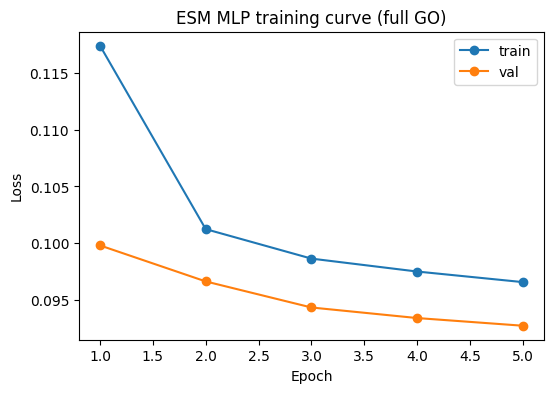

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o", label="train")
plt.plot(range(1, num_epochs + 1), val_losses, marker="o", label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ESM MLP training curve (full GO)")
plt.legend()
plt.show()

## Step 14. Reload the Best Checkpoint

### Why this step?
Instead of evaluating the final epoch directly, we reload the checkpoint with the best validation loss.

### Why this matters
This ensures that all downstream evaluation steps are based on the strongest saved version of the model, which is especially important for fair comparison against the k-mer baseline and future models.

In [16]:
best_model = ESMMLP(
    input_dim=X_train.shape[1],
    output_dim=Y_train.shape[1]
).to(device)

best_model.load_state_dict(torch.load(save_path, map_location=device))

<All keys matched successfully>

## Step 15. Generate Validation Predictions with the Best Model

### Why this step?
After reloading the best checkpoint, we run the model on the validation set to obtain:
- predicted GO probabilities
- true GO labels

### Why this is necessary
These predictions are required for threshold sweeping and final multi-label F1 evaluation.

In [17]:
val_probs, val_targets = get_predictions(best_model, val_loader, device)

print("val_probs shape:", val_probs.shape)
print("val_targets shape:", val_targets.shape)

val_probs shape: (28114, 31454)
val_targets shape: (28114, 31454)


## Step 16. Run Threshold Sweep and Identify Best Validation Thresholds

### Why this step?
This step evaluates how prediction quality changes across multiple probability thresholds.

Rather than assuming one threshold in advance, we search across several candidate values and identify:
- the threshold with the best micro-F1
- the threshold with the best macro-F1

### Why both thresholds are informative
- **Best micro-F1** reflects large-scale overall prediction quality
- **Best macro-F1** reflects behavior on the long-tail GO labels

In a highly imbalanced task, these may differ substantially.

In [18]:
thresholds = np.arange(0.05, 0.55, 0.05)
records, best_micro_row, best_macro_row = threshold_sweep(val_targets, val_probs, thresholds)

print("\nBest by micro-F1:", best_micro_row)
print("Best by macro-F1:", best_macro_row)

t=0.05 | micro-F1=0.0225 | macro-F1=0.0071
t=0.10 | micro-F1=0.0349 | macro-F1=0.0097
t=0.15 | micro-F1=0.0457 | macro-F1=0.0120
t=0.20 | micro-F1=0.0560 | macro-F1=0.0131
t=0.25 | micro-F1=0.0664 | macro-F1=0.0136
t=0.30 | micro-F1=0.0769 | macro-F1=0.0146
t=0.35 | micro-F1=0.0879 | macro-F1=0.0157
t=0.40 | micro-F1=0.0994 | macro-F1=0.0164
t=0.45 | micro-F1=0.1114 | macro-F1=0.0170
t=0.50 | micro-F1=0.1238 | macro-F1=0.0176

Best by micro-F1: {'threshold': 0.5, 'micro_f1': 0.12379250146201996, 'macro_f1': 0.01763377069451164}
Best by macro-F1: {'threshold': 0.5, 'micro_f1': 0.12379250146201996, 'macro_f1': 0.01763377069451164}


## Step 17. Save the Experiment Results

Saving the main outputs makes the experiment reproducible and easier to compare against:
- the k-mer baseline
- future ESM variants
- namespace-specific models
- structure-based approaches

### What we save
We store:
- model name
- input and output dimensions
- batch size and epoch count
- best validation loss
- best threshold-based F1 results
- training and validation loss history

### Why this is useful
This creates a compact experiment record that can be reused in reports, comparison tables, and future notebooks.

In [19]:
import json
batch_size = 64
results = {
    "model": "esm_mlp_full_go",
    "input_dim": int(X_train.shape[1]),
    "output_dim": int(Y_train.shape[1]),
    "batch_size": batch_size,
    "num_epochs": num_epochs,
    "best_val_loss": float(best_val_loss),
    "best_micro": best_micro_row,
    "best_macro": best_macro_row,
    "train_losses": train_losses,
    "val_losses": val_losses,
}

with open("esm_mlp_full_go_metrics.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved metrics to esm_mlp_full_go_metrics.json")

Saved metrics to esm_mlp_full_go_metrics.json


## Step 18. Summarize Threshold Sweep Results in Table Form

### Why this step?
A table makes it easy to inspect how prediction quality changes with the decision threshold.

### What this helps us understand
- whether performance is stable across nearby thresholds
- where the best operating point occurs
- whether micro-F1 and macro-F1 peak at similar or different thresholds

In [20]:
import pandas as pd

df_thresh = pd.DataFrame(records)
display(df_thresh)

,threshold,micro_f1,macro_f1
0,0.05,0.022507,0.007080
1,0.10,0.034912,0.009707
2,0.15,0.045726,0.012001
3,0.20,0.056047,0.013060
4,0.25,0.066351,0.013605
5,0.30,0.076923,0.014624
6,0.35,0.087912,0.015656
7,0.40,0.099397,0.016445
8,0.45,0.111395,0.017027
9,0.50,0.123793,0.017634


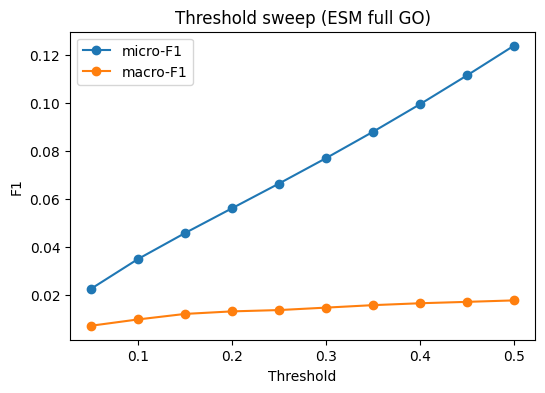

In [21]:
plt.figure(figsize=(6, 4))
plt.plot(df_thresh["threshold"], df_thresh["micro_f1"], marker="o", label="micro-F1")
plt.plot(df_thresh["threshold"], df_thresh["macro_f1"], marker="o", label="macro-F1")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title("Threshold sweep (ESM full GO)")
plt.legend()
plt.show()